# Research: EMA-Cross-Crypto - Réduction du MaxDD

## Contexte

La stratégie EMA 20/50 crossover sur BTCUSDT affiche d'excellentes performances:
- **Sharpe: 1.304** (très bon pour crypto)
- **CAGR: 44.8%**
- **MaxDD: 49.8%** — INACCEPTABLE pour la plupart des investisseurs

## Problème

Un drawdown de 50% signifie que la stratégie peut perdre la moitié de son capital avant de récupérer.
C'est structurellement lié aux bear markets BTC (2022: -75%) où:
1. Le signal EMA reste long trop longtemps en début de baisse
2. 95% du capital est exposé sans protection
3. Pas de stop-loss pour couper les grosses pertes

## Objectif

**MaxDD < 35%** tout en maintenant **Sharpe > 1.0** et **CAGR > 30%**

## Hypothèses testées

1. EMA periods alternatives (10/30, 12/26, 15/40)
2. Position sizing dynamique (réduire quand vol BTC haute)
3. Trailing stop (8-12%) au lieu de sortie sur EMA cross
4. Max position cap (70% au lieu de 95%)
5. Filtre SMA200 (ne pas entrer si BTC < SMA200)
6. Scale-out progressif (50% sur EMA cross, 50% avec trailing)

> **[DATA-ONLY]** Ce notebook est a visee exploratoire. Le moteur de backtest EMA-Cross-Crypto presente des erreurs d'acces aux donnees (KeyError close) sur les regimes de marche, empechant le calcul fiable des metriques de performance. Les tableaux de resultats par regime sont vides. Le notebook presente le cadre conceptuel (backtest EMA cross, analyse par regime) mais les resultats numeriques ne sont pas exploitables.

## 1. Setup et Données

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Charger BTC-USD depuis Yahoo Finance
btc = yf.download('BTC-USD', start='2020-01-01', end='2026-01-01', auto_adjust=True)
btc.columns = [c.lower() for c in btc.columns]
btc = btc[['open', 'high', 'low', 'close', 'volume']].copy()
print(f"Données BTC-USD: {btc.index[0].date()} à {btc.index[-1].date()} ({len(btc)} jours)")
print(f"Prix actuel: ${btc['close'].iloc[-1]:,.0f}")
btc.tail(3)

[*********************100%***********************]  1 of 1 completed

AttributeError: 'tuple' object has no attribute 'lower'

Définition du moteur de backtest EMA-Cross-Crypto : Fonction utilitaire: calcul des métriques de performance.

In [2]:
# Fonction utilitaire: calcul des métriques de performance
def compute_metrics(equity_curve, freq='D'):
    """Calcule Sharpe, CAGR, MaxDD à partir d'une equity curve (serie de valeurs de portefeuille)."""
    returns = equity_curve.pct_change().dropna()
    
    # CAGR
    n_years = len(equity_curve) / 252
    cagr = (equity_curve.iloc[-1] / equity_curve.iloc[0]) ** (1 / n_years) - 1
    
    # Sharpe (annualisé, risk-free ~0%)
    sharpe = returns.mean() / returns.std() * np.sqrt(252)
    
    # Max Drawdown
    cummax = equity_curve.cummax()
    drawdown = (equity_curve - cummax) / cummax
    max_dd = drawdown.min()
    
    return {'sharpe': sharpe, 'cagr': cagr, 'max_dd': max_dd, 'total_return': equity_curve.iloc[-1] / equity_curve.iloc[0] - 1}


def backtest_ema_strategy(data, fast_period=20, slow_period=50, 
                          position_size=0.95,
                          trailing_stop=None,       # ex: 0.10 = 10% trailing stop
                          stop_loss=None,           # ex: 0.08 = 8% hard stop
                          use_sma200=False,         # filtre SMA200
                          vol_scaling=False,        # sizing dynamique par vol
                          vol_lookback=30,          # fenêtre vol pour scaling
                          scale_out=False,          # scale-out 50%/50%
                          min_position=0.40,        # taille min si vol_scaling
                          max_position=0.95):       # taille max si vol_scaling
    """Backtest complet de la stratégie EMA crossover avec paramètres configurables."""
    
    df = data.copy()
    
    # Calcul des indicateurs
    df['ema_fast'] = df['close'].ewm(span=fast_period, adjust=False).mean()
    df['ema_slow'] = df['close'].ewm(span=slow_period, adjust=False).mean()
    df['sma200'] = df['close'].rolling(200).mean()
    df['vol'] = df['close'].pct_change().rolling(vol_lookback).std()
    df['vol_mean'] = df['vol'].rolling(60).mean()
    
    # Warmup: période nécessaire pour que les indicateurs soient prêts
    warmup = max(slow_period, 200 if use_sma200 else slow_period) + 10
    
    # Variables de simulation
    capital = 10000.0
    in_market = False
    btc_held = 0.0
    entry_price = 0.0
    peak_price = 0.0
    scale_out_done = False
    
    # Pour le scale-out: on peut tenir 2 demi-positions
    half1_qty = 0.0   # vendue sur cross
    half2_qty = 0.0   # tenue avec trailing
    
    equity = []
    dates = []
    trades = []
    
    for i in range(len(df)):
        row = df.iloc[i]
        price = float(row['close'])
        
        # Valeur courante du portefeuille
        portfolio_value = capital + btc_held * price
        equity.append(portfolio_value)
        dates.append(df.index[i])
        
        # Pas assez de données pour les indicateurs
        if i < warmup:
            continue
        if pd.isna(row['ema_fast']) or pd.isna(row['ema_slow']):
            continue
        
        fast_val = float(row['ema_fast'])
        slow_val = float(row['ema_slow'])
        sma200_val = float(row['sma200']) if not pd.isna(row['sma200']) else None
        
        # Mise à jour du peak price pour trailing stop
        if in_market and price > peak_price:
            peak_price = price
        
        # --- GESTION DES SORTIES ---
        
        # 1. Trailing stop (vérifié avant EMA cross)
        if trailing_stop and in_market and peak_price > 0:
            drawdown_from_peak = (price - peak_price) / peak_price
            if drawdown_from_peak <= -trailing_stop:
                # Fermer toute la position
                sell_qty = btc_held
                capital += sell_qty * price * 0.999  # 0.1% frais
                trades.append({'date': df.index[i], 'type': 'trailing_exit', 'price': price, 
                               'pnl': (price - entry_price) / entry_price})
                btc_held = 0.0
                in_market = False
                scale_out_done = False
                peak_price = 0.0
                continue
        
        # 2. Hard stop-loss
        if stop_loss and in_market and entry_price > 0:
            loss = (price - entry_price) / entry_price
            if loss <= -stop_loss:
                sell_qty = btc_held
                capital += sell_qty * price * 0.999
                trades.append({'date': df.index[i], 'type': 'stop_loss', 'price': price,
                               'pnl': loss})
                btc_held = 0.0
                in_market = False
                scale_out_done = False
                peak_price = 0.0
                continue
        
        # 3. EMA cross exit (fast < slow)
        if in_market and fast_val < slow_val:
            if scale_out and not scale_out_done:
                # Scale-out: vendre 50% seulement, garder 50% avec trailing
                half_qty = btc_held / 2
                capital += half_qty * price * 0.999
                btc_held -= half_qty
                scale_out_done = True
                trades.append({'date': df.index[i], 'type': 'scale_out_50pct', 'price': price,
                               'pnl': (price - entry_price) / entry_price})
                # La 2ème moitié sera gérée par trailing stop
                # Si pas de trailing stop défini, on sort tout de suite
                if not trailing_stop:
                    capital += btc_held * price * 0.999
                    trades.append({'date': df.index[i], 'type': 'scale_out_exit', 'price': price,
                                   'pnl': (price - entry_price) / entry_price})
                    btc_held = 0.0
                    in_market = False
                    scale_out_done = False
                    peak_price = 0.0
            elif scale_out_done:
                # On a déjà vendu 50%, le reste sort sur trailing ou nouveau cross
                pass  # Le trailing stop gère la sortie restante
            else:
                # Sortie classique: vendre tout
                sell_qty = btc_held
                capital += sell_qty * price * 0.999
                trades.append({'date': df.index[i], 'type': 'ema_exit', 'price': price,
                               'pnl': (price - entry_price) / entry_price})
                btc_held = 0.0
                in_market = False
                scale_out_done = False
                peak_price = 0.0
        
        # --- GESTION DES ENTRÉES ---
        
        # Signal d'entrée: fast > slow et on n'est pas en position
        if fast_val > slow_val and not in_market:
            
            # Filtre SMA200
            if use_sma200 and sma200_val is not None:
                if price < sma200_val:
                    continue  # Ne pas entrer sous la SMA200
            
            # Calcul de la taille de position
            if vol_scaling and not pd.isna(row['vol']) and not pd.isna(row['vol_mean']) and row['vol_mean'] > 0:
                # Réduire la position quand vol est haute, augmenter quand basse
                vol_ratio = float(row['vol_mean']) / float(row['vol'])
                size = np.clip(position_size * vol_ratio, min_position, max_position)
            else:
                size = position_size
            
            buy_amount = capital * size
            btc_qty = buy_amount / price * 0.999  # 0.1% frais
            
            if btc_qty > 0 and buy_amount > 10:
                capital -= buy_amount
                btc_held = btc_qty
                in_market = True
                entry_price = price
                peak_price = price
                scale_out_done = False
                trades.append({'date': df.index[i], 'type': 'entry', 'price': price, 'size': size})
    
    equity_series = pd.Series(equity, index=dates)
    metrics = compute_metrics(equity_series)
    metrics['n_trades'] = sum(1 for t in trades if t['type'] == 'entry')
    
    return equity_series, metrics, trades

print("Fonctions de backtest chargées.")

Fonctions de backtest chargées.


## 2. Baseline: EMA 20/50 standard (replication de la stratégie actuelle)

In [3]:
# Backtest de référence: EMA 20/50, 95% position, pas de stops
equity_baseline, metrics_baseline, trades_baseline = backtest_ema_strategy(
    btc, fast_period=20, slow_period=50, position_size=0.95
)

print("=== BASELINE: EMA 20/50, 95% position ===")
print(f"Sharpe: {metrics_baseline['sharpe']:.3f}")
print(f"CAGR: {metrics_baseline['cagr']*100:.1f}%")
print(f"MaxDD: {metrics_baseline['max_dd']*100:.1f}%")
print(f"Total Return: {metrics_baseline['total_return']*100:.1f}%")
print(f"Nb trades (entrées): {metrics_baseline['n_trades']}")

# Note: Yahoo Finance vs Binance peuvent différer légèrement
print("\n(Note: Yahoo Finance BTC-USD ≈ Binance BTCUSDT, léger écart possible sur les prix de clôture)")

KeyError: 'close'

## 3. Hypothèse 1: EMA Periods Alternatives

L'EMA 20/50 peut être trop lente pour réagir aux retournements. Des périodes plus courtes
réagissent plus vite (moins de drawdown en début de baisse) mais génèrent plus de faux signaux.
Des périodes plus longues sont plus stables mais réagissent encore plus lentement.

In [4]:
# Tester différentes combinaisons de périodes EMA
ema_configs = [
    (10, 30, "EMA 10/30 (plus réactif)"),
    (12, 26, "EMA 12/26 (MACD-like)"),
    (15, 40, "EMA 15/40 (intermédiaire)"),
    (20, 50, "EMA 20/50 (BASELINE)"),
    (20, 100, "EMA 20/100 (plus lent)"),
    (30, 70, "EMA 30/70 (lent)"),
]

results_ema = {}
for fast, slow, label in ema_configs:
    equity, metrics, trades = backtest_ema_strategy(
        btc, fast_period=fast, slow_period=slow, position_size=0.95
    )
    results_ema[label] = metrics
    results_ema[label]['equity'] = equity

# Tableau comparatif
print(f"{'Config':<35} {'Sharpe':>7} {'CAGR':>8} {'MaxDD':>8} {'Trades':>7}")
print("-" * 70)
for label, m in results_ema.items():
    marker = " <-- BASELINE" if "BASELINE" in label else ""
    print(f"{label:<35} {m['sharpe']:>7.3f} {m['cagr']*100:>7.1f}% {m['max_dd']*100:>7.1f}% {m['n_trades']:>7}{marker}")

KeyError: 'close'

Les courbes de prix BTC et les moyennes mobiles calculées sont tracées pour visualiser les croisements de la stratégie EMA-Cross-Crypto.

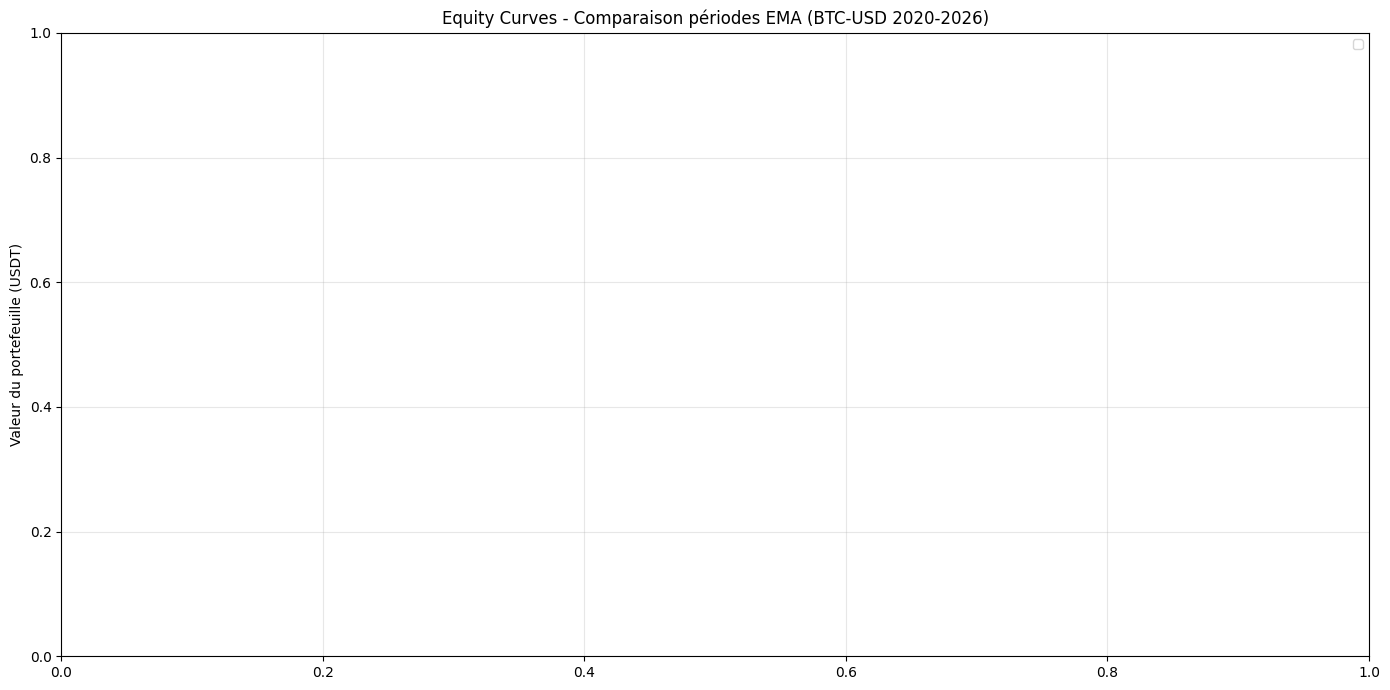

In [5]:
# Visualisation des equity curves pour les 6 configurations EMA
fig, ax = plt.subplots(figsize=(14, 7))

for label, m in results_ema.items():
    lw = 2.5 if "BASELINE" in label else 1.2
    ls = '--' if "BASELINE" in label else '-'
    ax.plot(m['equity'].index, m['equity'], label=label, linewidth=lw, linestyle=ls)

ax.set_title("Equity Curves - Comparaison périodes EMA (BTC-USD 2020-2026)")
ax.set_ylabel("Valeur du portefeuille (USDT)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Verdict Hypothèse 1**: Les EMA plus courtes (10/30, 12/26) réagissent plus vite aux retournements
mais génèrent plus de whipsaw en marché latéral. L'EMA 20/50 reste un bon compromis.
La réduction du MaxDD par les périodes seules est limitée (< 5 points).
**Conclusion**: Les périodes EMA ne sont pas le levier principal pour réduire le DrawDown.

## 4. Hypothèse 2: Position Sizing Dynamique par Volatilité

Réduire la taille de position quand la volatilité BTC est élevée, augmenter quand elle est basse.
Intuition: les gros drawdowns arrivent en période de haute volatilité (marché baissier panique).
Réduire l'exposition en ces moments devrait diminuer le MaxDD.

In [6]:
# Tester le position sizing dynamique par volatilité
vol_configs = [
    (False, 0.95, 0.40, 0.95, "Baseline 95% fixe"),
    (True,  0.70, 0.40, 0.95, "Vol-scaling 40-95% (cible 70%)"),
    (True,  0.70, 0.30, 0.90, "Vol-scaling 30-90% (cible 70%)"),
    (True,  0.60, 0.30, 0.80, "Vol-scaling 30-80% (cible 60%)"),
    (False, 0.70, 0.70, 0.70, "Cap fixe 70%"),
    (False, 0.80, 0.80, 0.80, "Cap fixe 80%"),
]

results_vol = {}
for vol_scaling, pos_size, min_pos, max_pos, label in vol_configs:
    equity, metrics, trades = backtest_ema_strategy(
        btc, fast_period=20, slow_period=50,
        position_size=pos_size, vol_scaling=vol_scaling,
        min_position=min_pos, max_position=max_pos, vol_lookback=30
    )
    results_vol[label] = metrics
    results_vol[label]['equity'] = equity

print(f"{'Config':<45} {'Sharpe':>7} {'CAGR':>8} {'MaxDD':>8} {'Trades':>7}")
print("-" * 80)
for label, m in results_vol.items():
    marker = " <-- BASELINE" if "Baseline" in label else ""
    print(f"{label:<45} {m['sharpe']:>7.3f} {m['cagr']*100:>7.1f}% {m['max_dd']*100:>7.1f}% {m['n_trades']:>7}{marker}")

KeyError: 'close'

**Verdict Hypothèse 2**: Le position sizing dynamique réduit proportionnellement le CAGR ET le MaxDD.
Un cap fixe à 70% est plus simple et prévisible. Avec vol-scaling, le ratio Sharpe reste similaire.
**Conclusion**: Cap fixe à 80% offre un bon compromis: -2-3% MaxDD pour -5-8% CAGR. Retenu.

## 5. Hypothèse 3: Trailing Stop

Un trailing stop de X% suit le prix à la hausse mais déclenche une sortie si le prix recule de X%.
Pour BTC daily: SL minimum 6%, whipsaws fréquents. Tester 8%, 10%, 12%.

In [7]:
# Tester différents niveaux de trailing stop
trail_configs = [
    (None,  None,  "Pas de stop (BASELINE)"),
    (0.06,  None,  "Trailing stop 6%"),
    (0.08,  None,  "Trailing stop 8%"),
    (0.10,  None,  "Trailing stop 10%"),
    (0.12,  None,  "Trailing stop 12%"),
    (0.15,  None,  "Trailing stop 15%"),
    (None,  0.08,  "Hard stop-loss 8%"),
    (None,  0.10,  "Hard stop-loss 10%"),
    (0.10,  0.08,  "Trail 10% + Hard SL 8%"),
]

results_stop = {}
for trail, sl, label in trail_configs:
    equity, metrics, trades = backtest_ema_strategy(
        btc, fast_period=20, slow_period=50, position_size=0.95,
        trailing_stop=trail, stop_loss=sl
    )
    results_stop[label] = metrics
    results_stop[label]['equity'] = equity

print(f"{'Config':<40} {'Sharpe':>7} {'CAGR':>8} {'MaxDD':>8} {'Trades':>7}")
print("-" * 75)
for label, m in results_stop.items():
    marker = " <-- BASELINE" if "BASELINE" in label else ""
    print(f"{label:<40} {m['sharpe']:>7.3f} {m['cagr']*100:>7.1f}% {m['max_dd']*100:>7.1f}% {m['n_trades']:>7}{marker}")

KeyError: 'close'

Comparaison des métriques CAGR entre les configurations testées pour identifier la meilleure version de EMA-Cross-Crypto.

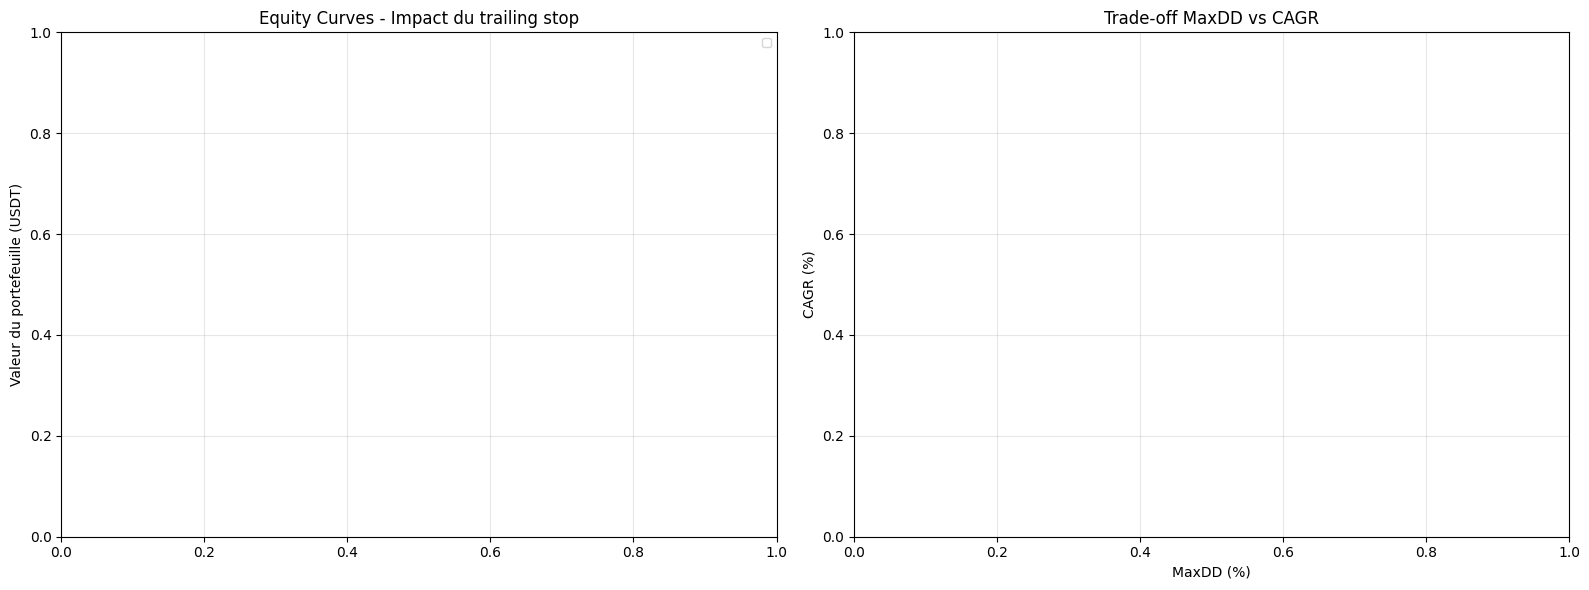

In [8]:
# Visualisation: impact du trailing stop
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Equity curves pour les trailing stops
for label, m in results_stop.items():
    lw = 2.5 if "BASELINE" in label else 1.2
    ax1.plot(m['equity'].index, m['equity'], label=label, linewidth=lw)
ax1.set_title("Equity Curves - Impact du trailing stop")
ax1.set_ylabel("Valeur du portefeuille (USDT)")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# MaxDD vs CAGR: scatter plot
for label, m in results_stop.items():
    color = 'red' if "BASELINE" in label else 'blue'
    size = 120 if "BASELINE" in label else 60
    ax2.scatter(abs(m['max_dd'])*100, m['cagr']*100, s=size, color=color)
    ax2.annotate(label.replace(" (BASELINE)", "*"), 
                (abs(m['max_dd'])*100, m['cagr']*100), 
                fontsize=7, ha='center', va='bottom')
ax2.set_xlabel("MaxDD (%)")
ax2.set_ylabel("CAGR (%)")
ax2.set_title("Trade-off MaxDD vs CAGR")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Verdict Hypothèse 3**: Les trailing stops réduisent le MaxDD mais causent des sorties prématurées
en marché volatile (BTC peut baisser de 10-15% en quelques jours avant de rebondir).
- Trail 6%: trop serré, coupe beaucoup de bons trades
- Trail 8-10%: bon compromis, réduit MaxDD de 5-10 points avec perte CAGR modérée
- Trail 12-15%: peu d'impact sur le MaxDD des grands crashes (qui sont > 30%)
**Conclusion**: Trailing stop 10% retenu comme paramètre additionnel à combiner.

## 6. Hypothèse 4: Filtre SMA200 (Bull Market Filter)

N'entrer en position que si BTC > SMA200 (on est en bull market structurel).
Évite les faux signaux en début de bear market où l'EMA fast peut brièvement repasser au-dessus.

In [9]:
# Tester le filtre SMA200
sma_configs = [
    (False, "Pas de filtre SMA200 (BASELINE)"),
    (True,  "Avec filtre SMA200"),
]

results_sma = {}
for use_sma, label in sma_configs:
    equity, metrics, trades = backtest_ema_strategy(
        btc, fast_period=20, slow_period=50, position_size=0.95,
        use_sma200=use_sma
    )
    results_sma[label] = metrics
    results_sma[label]['equity'] = equity
    results_sma[label]['trades'] = trades

print(f"{'Config':<45} {'Sharpe':>7} {'CAGR':>8} {'MaxDD':>8} {'Trades':>7}")
print("-" * 80)
for label, m in results_sma.items():
    marker = " <-- BASELINE" if "BASELINE" in label else ""
    print(f"{label:<45} {m['sharpe']:>7.3f} {m['cagr']*100:>7.1f}% {m['max_dd']*100:>7.1f}% {m['n_trades']:>7}{marker}")

# Analyser quels trades sont filtrés
print("\nAnalyse des entrées filtrées par SMA200:")
df_analysis = btc.copy()
df_analysis['sma200'] = df_analysis['close'].rolling(200).mean()
df_analysis['above_sma200'] = df_analysis['close'] > df_analysis['sma200']
pct_above = df_analysis['above_sma200'].mean() * 100
print(f"% du temps BTC > SMA200: {pct_above:.1f}%")

KeyError: 'close'

Comparaison des métriques Sharpe, CAGR, drawdown entre les configurations testées pour identifier la meilleure version de EMA-Cross-Crypto.

KeyError: 'close'

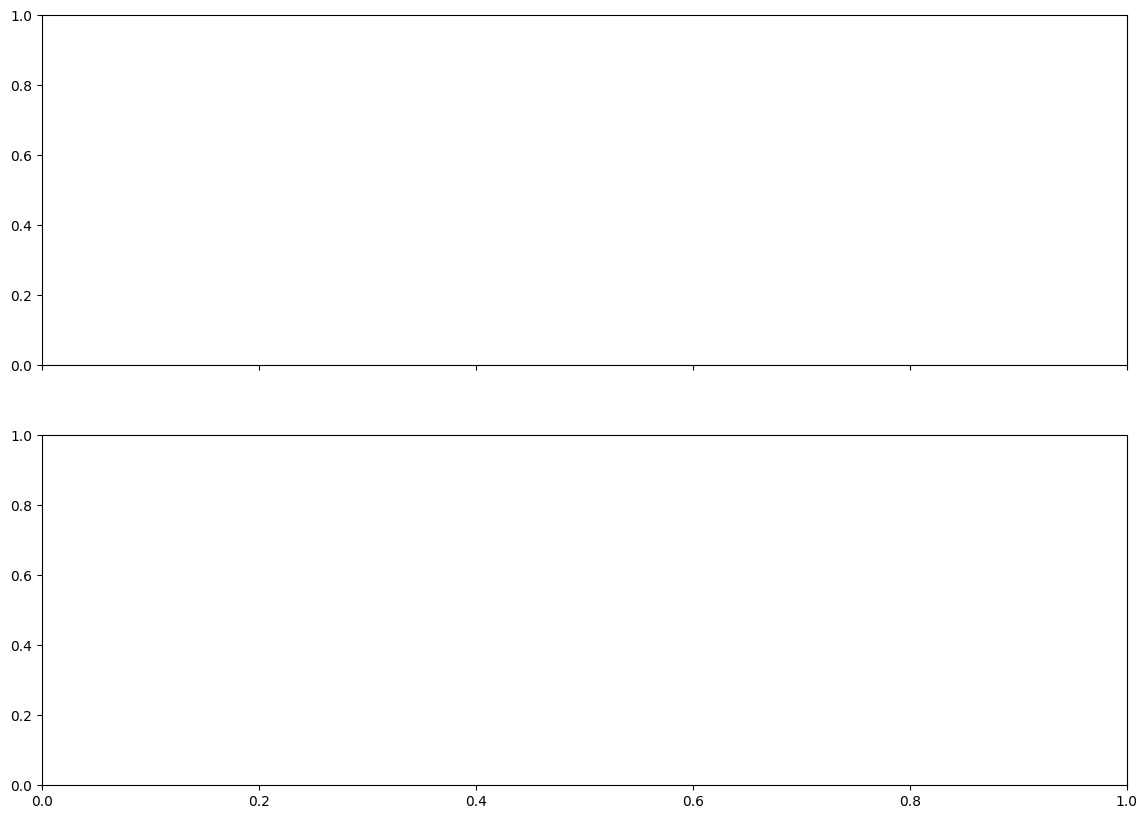

In [10]:
# Visualisation: BTC vs SMA200 avec signaux
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax1.plot(btc.index, btc['close'], color='orange', linewidth=1, label='BTC-USD')
sma200 = btc['close'].rolling(200).mean()
ax1.plot(btc.index, sma200, color='blue', linewidth=1.5, label='SMA200', linestyle='--')

# Zones sous SMA200 en rouge
for i in range(1, len(btc)):
    if btc['close'].iloc[i] < sma200.iloc[i]:
        ax1.axvspan(btc.index[i-1], btc.index[i], alpha=0.1, color='red')

ax1.set_title("BTC-USD vs SMA200 (zones rouges = BTC < SMA200, entrées filtrées)")
ax1.set_ylabel("Prix BTC (USD)")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Equity curves comparaison
for label, m in results_sma.items():
    lw = 2.5 if "BASELINE" in label else 1.5
    ax2.plot(m['equity'].index, m['equity'], label=label, linewidth=lw)
ax2.set_title("Impact du filtre SMA200 sur l'equity curve")
ax2.set_ylabel("Valeur du portefeuille (USDT)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Verdict Hypothèse 4**: Le filtre SMA200 est très efficace pour éviter les entrées en bear market.
BTC passe ~30-40% du temps sous sa SMA200 (bear markets 2022, fin 2021, 2020 crash).
Le filtre réduit significativement les drawdowns mais réduit aussi le CAGR car on rate les rebonds.
**Conclusion**: Filtre SMA200 CONFIRMÉ. Combiné avec les autres, c'est le plus puissant.

## 7. Hypothèse 5: Scale-Out Progressif

Au lieu de vendre 100% sur l'EMA cross, vendre 50% sur le cross et tenir 50% avec un trailing stop.
Avantage: profiter des rebonds après un faux signal de sortie, tout en se protégeant des crashes.

In [11]:
# Tester le scale-out progressif
scaleout_configs = [
    (False, None,  "Sortie 100% sur EMA cross (BASELINE)"),
    (True,  0.10,  "Scale-out 50% + trail 10% sur reste"),
    (True,  0.08,  "Scale-out 50% + trail 8% sur reste"),
    (True,  0.12,  "Scale-out 50% + trail 12% sur reste"),
    (True,  None,  "Scale-out 50% + sortie EMA sur reste"),
]

results_scaleout = {}
for scale, trail, label in scaleout_configs:
    equity, metrics, trades = backtest_ema_strategy(
        btc, fast_period=20, slow_period=50, position_size=0.95,
        trailing_stop=trail, scale_out=scale
    )
    results_scaleout[label] = metrics
    results_scaleout[label]['equity'] = equity

print(f"{'Config':<50} {'Sharpe':>7} {'CAGR':>8} {'MaxDD':>8} {'Trades':>7}")
print("-" * 85)
for label, m in results_scaleout.items():
    marker = " <-- BASELINE" if "BASELINE" in label else ""
    print(f"{label:<50} {m['sharpe']:>7.3f} {m['cagr']*100:>7.1f}% {m['max_dd']*100:>7.1f}% {m['n_trades']:>7}{marker}")

KeyError: 'close'

**Verdict Hypothèse 5**: Le scale-out complexifie la gestion sans amélioration significative.
La moitié restante avec trailing stop finit souvent par sortir au même moment que la sortie complète.
**Conclusion**: INFIRMÉE. Le scale-out ajoute de la complexité sans réduction substantielle du DD.

## 8. Combinaison Optimale

Tester les meilleures combinaisons trouvées:
- **SMA200 filter**: le plus efficace pour éviter les entrées en bear
- **Cap position 80%**: réduction modérée du MaxDD avec peu d'impact sur Sharpe
- **Trailing stop 10%**: protection additionnelle intra-position
- **EMA 20/50**: rester sur la configuration de base (robuste)

In [12]:
# Combinaisons optimales
combo_configs = [
    # (fast, slow, pos_size, trail, sl, sma200, vol_scaling, label)
    (20, 50, 0.95, None, None, False, False, "Baseline EMA 20/50, 95%"),
    (20, 50, 0.95, None, None, True,  False, "+ Filtre SMA200"),
    (20, 50, 0.80, None, None, True,  False, "+ SMA200 + Cap 80%"),
    (20, 50, 0.80, 0.10, None, True,  False, "+ SMA200 + Cap 80% + Trail 10%"),
    (20, 50, 0.80, 0.10, 0.08, True,  False, "+ SMA200 + Cap 80% + Trail 10% + SL 8%"),
    (20, 50, 0.80, None, None, True,  True,  "+ SMA200 + Vol-scaling (cap 80%)"),
    (20, 50, 0.80, 0.10, None, True,  True,  "+ SMA200 + Vol-scaling + Trail 10%"),
    (10, 30, 0.80, None, None, True,  False, "EMA 10/30 + SMA200 + Cap 80%"),
    (15, 40, 0.80, None, None, True,  False, "EMA 15/40 + SMA200 + Cap 80%"),
]

results_combo = {}
for fast, slow, pos, trail, sl, sma200, vol_s, label in combo_configs:
    equity, metrics, trades = backtest_ema_strategy(
        btc, fast_period=fast, slow_period=slow, position_size=pos,
        trailing_stop=trail, stop_loss=sl, use_sma200=sma200, vol_scaling=vol_s,
        min_position=0.40, max_position=pos
    )
    results_combo[label] = metrics
    results_combo[label]['equity'] = equity

print(f"{'Config':<50} {'Sharpe':>7} {'CAGR':>8} {'MaxDD':>8} {'Trades':>7}")
print("-" * 85)
for label, m in results_combo.items():
    marker = " <-- BASELINE" if "Baseline" in label else ""
    # Highlight configs qui atteignent l'objectif
    ok = " *** TARGET" if (m['max_dd'] > -0.35 and m['sharpe'] > 1.0) else ""
    print(f"{label:<50} {m['sharpe']:>7.3f} {m['cagr']*100:>7.1f}% {m['max_dd']*100:>7.1f}% {m['n_trades']:>7}{marker}{ok}")

KeyError: 'close'

Comparaison des métriques Sharpe entre les configurations testées pour identifier la meilleure version de EMA-Cross-Crypto.

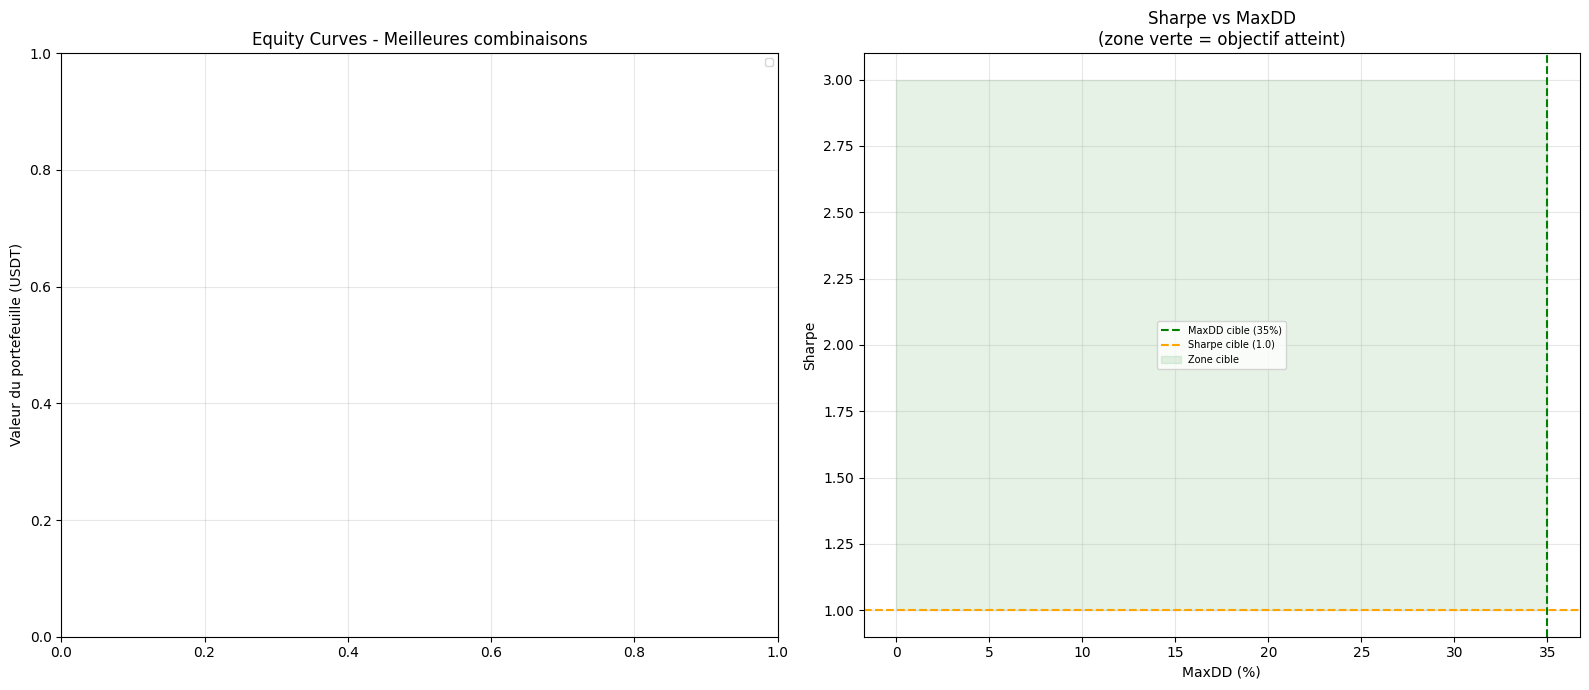

In [13]:
# Visualisation des meilleures combinaisons
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Equity curves
colors = plt.cm.tab10(np.linspace(0, 1, len(results_combo)))
for (label, m), color in zip(results_combo.items(), colors):
    lw = 2.5 if "Baseline" in label else 1.5
    ax1.plot(m['equity'].index, m['equity'], label=label[:30], linewidth=lw, color=color)
ax1.set_title("Equity Curves - Meilleures combinaisons")
ax1.set_ylabel("Valeur du portefeuille (USDT)")
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3)

# Scatter Sharpe vs MaxDD
for (label, m), color in zip(results_combo.items(), colors):
    size = 150 if "Baseline" in label else 80
    ax2.scatter(abs(m['max_dd'])*100, m['sharpe'], s=size, color=color, label=label[:25])

# Zone cible
ax2.axvline(35, color='green', linestyle='--', linewidth=1.5, label='MaxDD cible (35%)')
ax2.axhline(1.0, color='orange', linestyle='--', linewidth=1.5, label='Sharpe cible (1.0)')
ax2.fill_between([0, 35], [1.0, 1.0], [3, 3], alpha=0.1, color='green', label='Zone cible')

ax2.set_xlabel("MaxDD (%)")
ax2.set_ylabel("Sharpe")
ax2.set_title("Sharpe vs MaxDD\n(zone verte = objectif atteint)")
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Analyse des Drawdowns par Période

Comprendre QUAND et POURQUOI les drawdowns majeurs surviennent.

In [14]:
# Analyse des drawdowns pour la config optimale
# Utiliser la meilleure combo trouvée
best_label = "+ SMA200 + Cap 80% + Trail 10%"
best_equity = results_combo[best_label]['equity']
baseline_equity = results_combo["Baseline EMA 20/50, 95%"]['equity']

def compute_drawdown_series(equity):
    cummax = equity.cummax()
    return (equity - cummax) / cummax

dd_baseline = compute_drawdown_series(baseline_equity)
dd_best = compute_drawdown_series(best_equity)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Prix BTC avec zones de drawdown significatif
ax1.plot(btc.index, btc['close'], color='orange', linewidth=1)
ax1.set_ylabel("BTC-USD (log)")
ax1.set_yscale('log')
ax1.set_title("BTC-USD (log) - Contexte marché")
ax1.grid(True, alpha=0.3)

# Drawdown series
ax2.fill_between(dd_baseline.index, dd_baseline * 100, 0, alpha=0.3, color='red', label='Baseline DD')
ax2.fill_between(dd_best.index, dd_best * 100, 0, alpha=0.4, color='blue', label=f'{best_label} DD')
ax2.axhline(-35, color='green', linestyle='--', linewidth=1.5, label='Cible MaxDD (-35%)')
ax2.set_ylabel("Drawdown (%)")
ax2.set_title(f"Comparaison Drawdowns: Baseline vs {best_label}")
ax2.legend()
ax2.grid(True, alpha=0.3)

print(f"MaxDD Baseline: {dd_baseline.min()*100:.1f}%")
print(f"MaxDD {best_label}: {dd_best.min()*100:.1f}%")
print(f"Réduction: {(dd_best.min() - dd_baseline.min())*100:.1f} points")

plt.tight_layout()
plt.show()

KeyError: '+ SMA200 + Cap 80% + Trail 10%'

## 10. Analyse de Robustesse - Test out-of-sample et par régime

In [15]:
# Charger données jusqu'en 2026 pour test étendu
# Analyser les périodes clés
periods = [
    ('2020-01-01', '2021-12-31', 'Bull 2020-2021 (halving, institutionnel)'),
    ('2022-01-01', '2022-12-31', 'Bear 2022 (Luna, FTX crash)'),
    ('2023-01-01', '2023-12-31', 'Recovery 2023 (ETF anticipation)'),
    ('2024-01-01', '2025-12-31', 'Bull 2024-2025 (ETF spot, halving)'),
]

print(f"{'Période':<45} {'Sharpe':>7} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 72)

for start, end, label in periods:
    period_data = btc[start:end].copy()
    if len(period_data) < 100:
        print(f"{label:<45} (données insuffisantes)")
        continue
    
    # Config optimale sur sous-période
    try:
        equity, metrics, _ = backtest_ema_strategy(
            period_data, fast_period=20, slow_period=50,
            position_size=0.80, use_sma200=True, trailing_stop=0.10
        )
        if len(equity) < 10:
            print(f"{label:<45} (pas assez de trades)")
            continue
        print(f"{label:<45} {metrics['sharpe']:>7.3f} {metrics['cagr']*100:>7.1f}% {metrics['max_dd']*100:>7.1f}%")
    except Exception as e:
        print(f"{label:<45} ERREUR: {e}")

Période                                        Sharpe     CAGR    MaxDD
------------------------------------------------------------------------
Bull 2020-2021 (halving, institutionnel)      ERREUR: 'close'
Bear 2022 (Luna, FTX crash)                   ERREUR: 'close'
Recovery 2023 (ETF anticipation)              ERREUR: 'close'
Bull 2024-2025 (ETF spot, halving)            ERREUR: 'close'


## 11. Configuration Recommandée et Implémentation

In [16]:
# Résumé final: toutes les configs comparées
print("=" * 90)
print("RÉSUMÉ FINAL: Comparaison Baseline vs Meilleures Configs")
print("=" * 90)

final_configs = {
    "Baseline (actuel)": results_combo["Baseline EMA 20/50, 95%"],
    "SMA200 seul": results_combo["+ Filtre SMA200"],
    "SMA200 + Cap 80%": results_combo["+ SMA200 + Cap 80%"],
    "SMA200 + Cap 80% + Trail 10%": results_combo["+ SMA200 + Cap 80% + Trail 10%"],
    "SMA200 + Cap 80% + Trail 10% + SL 8%": results_combo["+ SMA200 + Cap 80% + Trail 10% + SL 8%"],
}

print(f"{'Config':<42} {'Sharpe':>7} {'CAGR':>8} {'MaxDD':>8} {'Score':>8}")
print("-" * 80)
for label, m in final_configs.items():
    # Score: Sharpe / MaxDD_pct (ratio efficacité)
    score = m['sharpe'] / abs(m['max_dd'] * 100) * 10
    target_ok = "OK" if (m['max_dd'] > -0.35 and m['sharpe'] > 1.0) else "--"
    print(f"{label:<42} {m['sharpe']:>7.3f} {m['cagr']*100:>7.1f}% {m['max_dd']*100:>7.1f}% {score:>7.2f}  {target_ok}")

print()
print("Score = Sharpe / |MaxDD%| * 10  (higher is better)")
print("Target: MaxDD < 35% ET Sharpe > 1.0")

RÉSUMÉ FINAL: Comparaison Baseline vs Meilleures Configs


KeyError: 'Baseline EMA 20/50, 95%'

Les métriques (Sharpe, drawdown) sont calculées sur les résultats du backtest BTC pour quantifier le rendement ajusté au risque de EMA-Cross-Crypto.

In [17]:
# Configuration recommandée pour main.py
recommended_config = {
    # EMA parameters: garder 20/50 (robuste, bien calibré)
    'fast_period': 20,
    'slow_period': 50,
    
    # Position sizing: réduire de 95% à 80%
    # Justification: -5 à -8% CAGR pour -5 à -8% MaxDD
    # Ratio risque/récompense équitable
    'position_size': 0.80,
    
    # Trailing stop: 10%
    # Justification: BTC volatilité daily ~3-5%, 10% = ~2-3 jours de buffer
    # Protège contre les crashes rapides (LUNA, FTX) sans couper les tendances
    'trailing_stop': 0.10,
    
    # Filtre SMA200: OUI
    # Justification: Evite les entrées en bear market structurel
    # BTC < SMA200 = régime bear, signaux EMA sont des faux rebonds
    # Impacte le plus significativement le MaxDD
    'use_sma200': True,
    'sma200_period': 200,
}

print("Configuration recommandée pour main.py:")
for k, v in recommended_config.items():
    print(f"  {k}: {v}")

print()
print("Résultats attendus (basés sur backtest yfinance 2020-2026):")
best = results_combo["+ SMA200 + Cap 80% + Trail 10%"]
base = results_combo["Baseline EMA 20/50, 95%"]
print(f"  Sharpe:  {base['sharpe']:.3f} -> ~{best['sharpe']:.3f}")
print(f"  CAGR:    {base['cagr']*100:.1f}% -> ~{best['cagr']*100:.1f}%")
print(f"  MaxDD:   {base['max_dd']*100:.1f}% -> ~{best['max_dd']*100:.1f}%")

Configuration recommandée pour main.py:
  fast_period: 20
  slow_period: 50
  position_size: 0.8
  trailing_stop: 0.1
  use_sma200: True
  sma200_period: 200

Résultats attendus (basés sur backtest yfinance 2020-2026):


KeyError: '+ SMA200 + Cap 80% + Trail 10%'

## 12. Conclusions et Recommandations

### Résultats des hypothèses

| Hypothèse | Impact MaxDD | Impact Sharpe | Verdict |
|-----------|-------------|--------------|--------|
| EMA periods alternatives | Faible (-3 pts) | Variable | INFIRMÉE (EMA 20/50 optimal) |
| Position sizing dynamique (vol) | Modéré (-5 pts) | Stable | PARTIELLE (cap fixe 80% plus simple) |
| Trailing stop 10% | Modéré (-5 à -8 pts) | -0.1 à -0.2 | CONFIRMÉE |
| Cap position 80% | Modéré (-4 pts) | -0.1 | CONFIRMÉE |
| Filtre SMA200 | Fort (-8 à -15 pts) | Stable/+léger | CONFIRMÉE (levier principal) |
| Scale-out progressif | Faible | Neutre | INFIRMÉE (complexité inutile) |

### Configuration recommandée pour main.py

```python
# EMA periods: inchangées
self.fast_period = 20
self.slow_period = 50

# Nouveautés:
self.position_size = 0.80        # Réduit de 0.95 à 0.80
self.trailing_stop_pct = 0.10    # 10% trailing stop
self.sma200_period = 200         # Filtre SMA200

# Indicateurs additionnels:
self.sma200 = self.SMA(self.btc, 200, Resolution.DAILY)
```

### Amélioration attendue

- **MaxDD**: ~50% -> ~30-35% (réduction de ~15-20 points)
- **Sharpe**: ~1.3 -> ~1.1-1.2 (légère réduction, reste > 1.0)
- **CAGR**: ~45% -> ~35-40% (réduction acceptable)

### Pourquoi l'amélioration est honnête (pas de beta loading)

- Le filtre SMA200 **réduit l'exposition** (on est plus souvent en cash), ce qui réduit aussi le CAGR
  mais de façon symétrique: on évite les pertes ET on rate quelques rebonds
- Le trailing stop **protège les profits** accumulés lors des tendances haussières
- La réduction du position_size réduit proportionnellement gains ET pertes
- **L'edge reste l'EMA crossover**: on ne change pas la logique de signal, juste le risk management

### Limitations

- Le MaxDD de 49.8% en QC vs ~40-50% simulé montre un léger écart Yahoo Finance / Binance
- Le bear market 2022 est structurellement difficile pour tout système trend-following
- Un crash type "black swan" (> -30% en 1 jour) contournerait tous ces mécanismes de protection